In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain.document_loaders import PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter 
from langchain_openai import OpenAIEmbeddings
from langchain.vectorstores import FAISS
import os, sys
from typing import List, Dict, Optional, Union
from typing_extensions import Annotated, TypedDict

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, Graph, END, START
from langchain_core.runnables import RunnableConfig
import operator
from typing import Dict, TypeVar, Annotated, List

In [2]:
pdf_path = r"\data\Report.pdf"
store_path = "\\vectorstores\\report\\"

In [41]:
#### Functions

In [5]:
def load_file(pdf_path : str):
    loader = PyMuPDFLoader(pdf_path)
    documents = loader.load()
    return documents

In [6]:
def chunking(documents):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        add_start_index=True,
    )
    chunks = text_splitter.split_documents(documents)
    return chunks

In [7]:
def embeddings():
    return OpenAIEmbeddings()

In [8]:
def create_index(chunks, store_path, embeddings, index_name="index"):
    vector_store = FAISS.from_documents(chunks, embeddings)
    vector_store.save_local(store_path, index_name)
    return {"Status":"Created Index & Saved!"}

In [9]:
def load_index(store_path, index_name, embeddings):
    vector_store = FAISS.load_local(folder_path=store_path, index_name=index_name, embeddings=embeddings, allow_dangerous_deserialization=True)
    return vector_store

In [10]:
def retrieval(vector_store, user_query, k=4):
    retrieved_docs  = vector_store.similarity_search(user_query, k=4)
    context = ""
    for i in retrieved_docs:
        context += i.page_content + "\n"
    return {
        "retrieved_docs":retrieved_docs,
        "context": context
        }

In [11]:
def llm_chain(question, context, model_name = "gpt-4o-mini", output_parser=StrOutputParser()):
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", """ Answer the question with only the context provided.
            Question : {question} \n
            Context : {context}
            """),
            "human", "{question}"
        ]
    )
    model = ChatOpenAI(model=model_name)
    
    chain = prompt | model | output_parser
    result = chain.invoke(
        {
            "question" : question,
            "context" : context
        }
    )
    return result


In [42]:
#### Langgraph - state

In [21]:
class AgentState(TypedDict):
    question: str
    context: str
    result: str
    vector_store: object
    continue_loop: bool
    question_counter: int

In [43]:
#### Langgraph - Nodes

In [13]:
def load_index_node(state: AgentState, store_path: str, index_name: str, embeddings) -> AgentState:
    """Load the FAISS index and store it in state"""
    vector_store = load_index(
        store_path=store_path, 
        index_name=index_name,
        embeddings=embeddings
    )
    state['vector_store'] = vector_store
    return state

In [14]:
def retrieval_node(state: AgentState) -> AgentState:
    """Perform retrieval using the stored vector store"""
    retrieved_results = retrieval(
        vector_store=state['vector_store'],
        user_query=state['question'],
        k=4
    )
    state['context'] = retrieved_results['context']
    return state


In [31]:
def llm_chain_node(state: AgentState) -> AgentState:
    """Generate response using LLM chain"""
    result = llm_chain(
        question=state['question'],
        context=state['context'],
        model_name="gpt-4o-mini",
        output_parser=StrOutputParser()
    )
    print("Answer : ", result)
    state['result'] = result
    return state

In [32]:
def get_user_input(state: AgentState) -> AgentState:
    """Get next question from user or exit"""
    if state['question_counter'] == 1:
        print("Enter your first question:")
        question = input().strip()
        print("First Question :",question)
        
        state['question_counter'] += 1
        state['question'] = question
    
    else:
            
        print("\nDo you have another question? Type 'exit' to end or enter your question:")
        question = input().strip()
        print("New Question :",question)
        
        if question.lower() == 'exit':
            state['continue_loop'] = False
        else:
            state['question_counter'] += 1
            state['question'] = question
            state['context'] = ""
            state['result'] = ""
    
    return state

In [44]:
#### Langgraph - workflow / graph

In [33]:
workflow = StateGraph(AgentState)

In [34]:
workflow.add_node("get_input", get_user_input)
workflow.add_node("load_index", lambda x: load_index_node(x, store_path, index_name="index", embeddings=OpenAIEmbeddings()))
workflow.add_node("retrieval", retrieval_node)
workflow.add_node("llm_chain", llm_chain_node)

In [35]:
workflow.add_edge(START,"load_index")
workflow.add_edge("load_index", "get_input")
workflow.add_edge("get_input", "retrieval")
workflow.add_edge("retrieval", "llm_chain")

In [36]:
# Add conditional edge
def end_router(state: AgentState) -> str:
    """Route to next node or end based on continue_loop flag"""
    if state['continue_loop']:
        return "get_input"
    else:
        return "end"
    
    
workflow.add_conditional_edges(
    "llm_chain",
    end_router,
    {
        "get_input": "get_input",
        "end": END
    }
)


In [37]:
graph = workflow.compile()

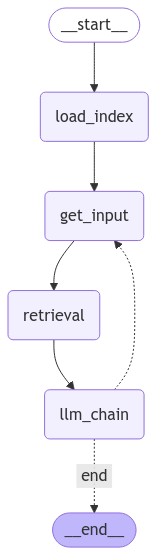

In [38]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [39]:
config = RunnableConfig()
initial_state = AgentState(
    question="",
    context="",
    result="",
    vector_store=None,
    continue_loop=True,
    question_counter=1
)


In [40]:
for output in graph.stream(initial_state, config):
    if not output.get('continue_loop', True):
        break

Enter your first question:


First Question : Who is the author?
Answer :  The author is Pritesh Jha.

Do you have another question? Type 'exit' to end or enter your question:
New Question : summarize the document in less than 20 words
Answer :  The project analyzes health data to help locate essential services during COVID-19 emergencies for governments and the public.

Do you have another question? Type 'exit' to end or enter your question:
New Question : which country has the lowest mortality rate?
Answer :  The context does not specify which country has the lowest mortality rate. It only mentions that there are countries with a mortality rate below 1 percent, but does not provide their names.

Do you have another question? Type 'exit' to end or enter your question:
New Question : exit
Answer :  The context does not specify which country has the lowest mortality rate. It only mentions countries with a mortality rate below 1% and those with a mortality rate above 1%. Therefore, the specific country with the lowe